In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [41]:
# Use the dataset you generated earlier
csv_path = "Crop_recommendation_with_soil_features.csv"

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2200, 12)


,N,P,K,temperature,humidity,ph,rainfall,label,soil_temperature_c,soil_moisture_pct,soil_temperature,soil_moisture
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,17.6,82,17.6°C,82%
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,18.2,83,18.2°C,83%
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,19.8,97,19.8°C,97%
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,23.8,85,23.8°C,85%
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,16.5,92,16.5°C,92%


In [42]:
feature_cols = [
    "N", "P", "K",
    "temperature", "humidity", "ph", "rainfall",
    "soil_temperature_c", "soil_moisture_pct"
]

X = df[feature_cols]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2200, 9)
y shape: (2200,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 1760
Test size : 440


In [44]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=6,
    min_samples_split=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✅ Model trained")


✅ Model trained


In [45]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")


Train Accuracy : 0.9972
Test Accuracy  : 0.9909


In [46]:
print("\nClassification Report (Test set):")
print(classification_report(y_test, y_test_pred))



Classification Report (Test set):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00   

In [47]:
cv_scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy :", cv_scores.std())


CV Scores: [0.99545455 0.98636364 0.99318182 0.99090909 0.98181818]
Mean CV Accuracy: 0.9895454545454545
Std CV Accuracy : 0.004895604370122289


In [48]:
# 5-fold cross-validation on the whole dataset
cv_scores = cross_val_score(rf_clf, X, y, cv=5, scoring="accuracy", n_jobs=-1)

print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy :", cv_scores.std())



Cross-validation accuracies: [0.99772727 0.99318182 0.99545455 0.99545455 0.98409091]
Mean CV accuracy: 0.9931818181818182
Std CV accuracy : 0.004767312946227944


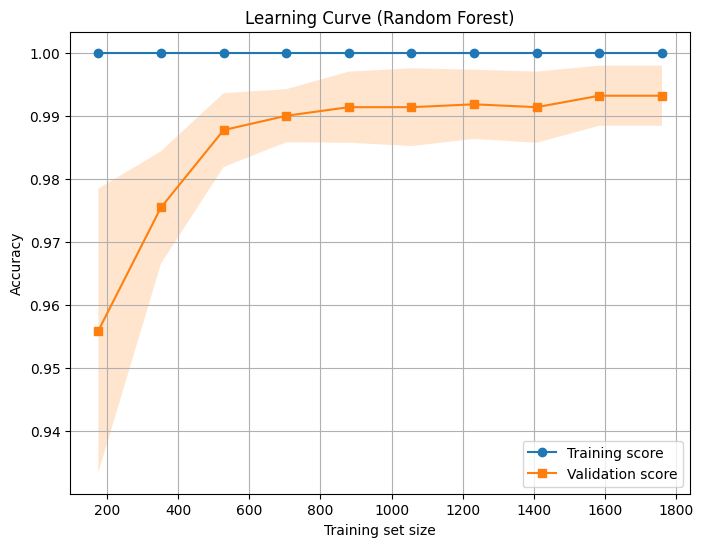

In [49]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_clf,
    X, y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, marker="s", label="Validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("Crop_recommendation_with_soil_features.csv")

feature_cols = [
    "N", "P", "K",
    "temperature", "humidity", "ph", "rainfall",
    "soil_temperature_c", "soil_moisture_pct"
]

X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=6,
    min_samples_split=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("✅ Model ready for prediction")


✅ Model ready for prediction


In [51]:
import pandas as pd

test_samples = pd.DataFrame([
    # 1️⃣ Rice-like conditions
    {
        "N": 90, "P": 40, "K": 40,
        "temperature": 28,
        "humidity": 80,
        "ph": 6.5,
        "rainfall": 200,
        "soil_temperature_c": 25,
        "soil_moisture_pct": 85
    },

    # 2️⃣ Wheat-like conditions
    {
        "N": 110, "P": 50, "K": 45,
        "temperature": 20,
        "humidity": 55,
        "ph": 6.8,
        "rainfall": 70,
        "soil_temperature_c": 17,
        "soil_moisture_pct": 50
    },

    # 3️⃣ Cotton-like conditions
    {
        "N": 120, "P": 60, "K": 55,
        "temperature": 30,
        "humidity": 50,
        "ph": 7.0,
        "rainfall": 60,
        "soil_temperature_c": 26,
        "soil_moisture_pct": 45
    },

    # 4️⃣ Banana-like conditions
    {
        "N": 100, "P": 75, "K": 50,
        "temperature": 27,
        "humidity": 85,
        "ph": 6.2,
        "rainfall": 180,
        "soil_temperature_c": 23,
        "soil_moisture_pct": 90
    },

    # 5️⃣ Maize-like conditions
    {
        "N": 85, "P": 55, "K": 45,
        "temperature": 24,
        "humidity": 65,
        "ph": 6.7,
        "rainfall": 100,
        "soil_temperature_c": 21,
        "soil_moisture_pct": 60
    },

    # 6️⃣ Dry / low rainfall scenario
    {
        "N": 60, "P": 30, "K": 30,
        "temperature": 34,
        "humidity": 35,
        "ph": 7.2,
        "rainfall": 30,
        "soil_temperature_c": 30,
        "soil_moisture_pct": 25
    }
])

test_samples


,N,P,K,temperature,humidity,ph,rainfall,soil_temperature_c,soil_moisture_pct
0,90,40,40,28,80,6.5,200,25,85
1,110,50,45,20,55,6.8,70,17,50
2,120,60,55,30,50,7.0,60,26,45
3,100,75,50,27,85,6.2,180,23,90
4,85,55,45,24,65,6.7,100,21,60
5,60,30,30,34,35,7.2,30,30,25


In [52]:
predictions = rf.predict(test_samples)

results = test_samples.copy()
results["Predicted Crop"] = predictions

results


,N,P,K,temperature,humidity,ph,rainfall,soil_temperature_c,soil_moisture_pct,Predicted Crop
0,90,40,40,28,80,6.5,200,25,85,rice
1,110,50,45,20,55,6.8,70,17,50,coffee
2,120,60,55,30,50,7.0,60,26,45,coffee
3,100,75,50,27,85,6.2,180,23,90,banana
4,85,55,45,24,65,6.7,100,21,60,coffee
5,60,30,30,34,35,7.2,30,30,25,muskmelon
